# Pontifícia Universidade Católica de Minas Gerais
## Pós-Graduação em IA Generativa e Aplicações com LLMs
### Disciplina: Arquiteturas de Deep Learning

# Predição de Churn com Redes Neurais (MLP)

> Nesta atividade, vamos treinar uma rede neural MLP para prever se um cliente irá cancelar ou permanecer na empresa.

---

| Campo | Detalhe |
|:------|:--------|
| **Instituição** | Pontifícia Universidade Católica de Minas Gerais |
| **Programa** | Pós-Graduação em IA Generativa e Aplicações com LLMs |
| **Disciplina** | Arquiteturas de Deep Learning |
| **Professor** | Antônio dos Santos Ramos Neto |
| **Aluno** | Jair Pereira da Silva Junior |
| **Dataset** | `Telco-Customer-Churn.csv` — 7.043 registros |
| **Fonte** | [Github - Dataset](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv) |
| **Objetivo** | Treinar uma rede MLP para classificação binária de churn e analisar overfitting/underfitting. |
| **Data de Entrega** | 01/06/2026 |

## 1. Importações

Antes de começar qualquer análise, precisamos **importar as bibliotecas** que vamos usar.

Em Python, uma **biblioteca** é um conjunto de funções prontas que outras pessoas desenvolveram e disponibilizaram gratuitamente. Em vez de programar tudo do zero, importamos essas ferramentas.

| Biblioteca | Para que serve |
|:-----------|:--------------|
| `pandas` | Manipulação de tabelas de dados (como planilhas Excel no código) |
| `numpy` | Operações matemáticas eficientes com arrays e matrizes |
| `matplotlib` | Criação de gráficos e visualizações |
| `seaborn` | Gráficos estatísticos com visual aprimorado (construído sobre o matplotlib) |
| `sklearn` | Machine Learning: divisão de dados, pré-processamento, modelos e métricas |

In [1]:
%matplotlib inline
# %matplotlib inline é uma "magic command" do Jupyter.
# Ela instrui o notebook a capturar e exibir os gráficos diretamente nas células de output,
# sem precisar de janela separada. É o modo padrão para notebooks interativos.

import pandas as pd        # "import ... as apelido" carrega a biblioteca com um nome curto
import numpy as np         # Por convenção: pandas→pd, numpy→np, pyplot→plt
import matplotlib.pyplot as plt  # pyplot é o submódulo onde ficam as funções de plotagem
import seaborn as sns      # Gráficos estatísticos com estilo aprimorado

# --- Scikit-learn (sklearn): a principal biblioteca de Machine Learning do Python ---
from sklearn.model_selection import train_test_split  # Divide dados em treino e teste
from sklearn.preprocessing import StandardScaler       # Normaliza os dados (Z-score)
from sklearn.neural_network import MLPClassifier       # Nossa rede neural MLP!
from sklearn.metrics import (
    classification_report,   # Relatório completo com Precision, Recall, F1
    confusion_matrix,         # Tabela que mostra acertos e erros por classe
    roc_auc_score,            # Área sob a curva ROC (métrica de qualidade geral)
    roc_curve,                # Coordenadas (FPR, TPR) para desenhar a curva ROC
    ConfusionMatrixDisplay,   # Visualização gráfica da matriz de confusão
    f1_score,                 # Média harmônica entre Precision e Recall
    precision_score,          # Dos que previmos como churn, quantos eram churn de fato?
    recall_score              # Dos que eram churn, quantos identificamos corretamente?
)

import warnings
warnings.filterwarnings('ignore')  # Oculta mensagens de aviso para manter o output limpo

# Definimos uma "semente aleatória" para garantir reprodutibilidade:
# ao rodar o código novamente, os resultados serão sempre os mesmos.
# O número 42 é convencional (referência ao livro "O Guia do Mochileiro das Galáxias").
np.random.seed(42)

# Verificamos as versões instaladas — útil para documentar o ambiente de execução
print('Pandas  :', pd.__version__)
print('NumPy   :', np.__version__)
import sklearn; print('sklearn :', sklearn.__version__)

Pandas  : 3.0.3
NumPy   : 2.4.4
sklearn : 1.8.0


## 2. Carregamento e Exploração dos Dados

### O que é Análise Exploratória de Dados (EDA)?

Antes de treinar qualquer modelo, precisamos **entender os dados** com os quais trabalhamos. Essa etapa chama-se **EDA (Exploratory Data Analysis)** e nos ajuda a:

- Conhecer a estrutura do dataset (linhas, colunas, tipos de dados)
- Identificar valores ausentes ou inconsistentes
- Entender a distribuição das variáveis
- Descobrir padrões e relações entre as colunas

### O que é um DataFrame?

Um **DataFrame** é como uma tabela (planilha Excel) dentro do Python. Ele possui:
- **Linhas** → cada linha representa um cliente (chamado de observação ou exemplo)
- **Colunas** → cada coluna representa uma característica do cliente (chamada de feature ou atributo)

In [2]:
# pd.read_csv() lê um arquivo CSV e transforma em um DataFrame do pandas.
# CSV (Comma-Separated Values) é um formato de texto onde cada linha é um registro
# e os valores de cada coluna são separados por vírgula.
df = pd.read_csv('Telco-Customer-Churn.csv')

# A variável "df" é a convenção para "dataframe" — você poderia chamar de qualquer nome,
# mas "df" é o padrão amplamente adotado pela comunidade de Data Science.

# .shape retorna uma tupla (linhas, colunas) — quantos registros e atributos o dataset tem
print(f'Shape: {df.shape}')
# f-string: forma moderna de inserir variáveis dentro de strings.
# Tudo entre {} é avaliado como código Python antes de ser exibido.

# .head(N) exibe as N primeiras linhas do DataFrame (padrão: 5 se omitido).
# Serve para ter uma "primeira impressão" de como os dados estão organizados.
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# .info() exibe um resumo técnico do DataFrame, mostrando para cada coluna:
#   - Nome da coluna
#   - Quantidade de valores não-nulos (Non-Null Count) — ajuda a detectar dados faltantes
#   - Tipo de dado (dtype)
#
# Tipos de dados mais comuns:
#   int64   → número inteiro sem casas decimais (ex: 0, 1, 34)
#   float64 → número com casas decimais (ex: 29.85, 1889.50)
#   object  → texto / string (ex: "Yes", "No", "Male", "Female")
#
# ATENÇÃO: note que TotalCharges aparece como "object" (texto) mesmo sendo um valor
# monetário! Isso é um problema que vamos corrigir na etapa de limpeza.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# .describe() calcula estatísticas resumidas das colunas numéricas:
#   count  → quantidade de valores não-nulos (para detectar dados faltantes)
#   mean   → média aritmética dos valores
#   std    → desvio padrão (mede o quanto os valores se afastam da média)
#   min    → menor valor encontrado
#   25%    → 1º quartil: 25% dos valores estão abaixo deste número
#   50%    → mediana: o valor do meio quando ordenamos os dados
#   75%    → 3º quartil: 75% dos valores estão abaixo deste número
#   max    → maior valor encontrado
#
# include='all' força a inclusão também das colunas de texto (object), que mostram:
#   unique → quantos valores distintos existem
#   top    → o valor mais frequente
#   freq   → quantas vezes o valor mais frequente aparece
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


### 2.1 Distribuição do Target (Churn)

#### O que é a variável target?

Em Machine Learning, chamamos de **target** (ou variável alvo) a coluna que queremos **prever**. No nosso caso é a coluna `Churn`:
- `No`  → o cliente **não** cancelou o serviço
- `Yes` → o cliente **cancelou** o serviço

#### Por que analisar a distribuição do target?

Se o dataset tiver, por exemplo, 95% `No` e 5% `Yes`, um modelo burro que sempre prevê "Não Churn" teria 95% de acurácia sem aprender nada! Isso se chama **desbalanceamento de classes** e precisa ser identificado antes de treinar.

Vamos visualizar com dois gráficos complementares:
- **Gráfico de barras** → quantidade absoluta de clientes em cada classe
- **Gráfico de pizza** → proporção percentual de cada classe

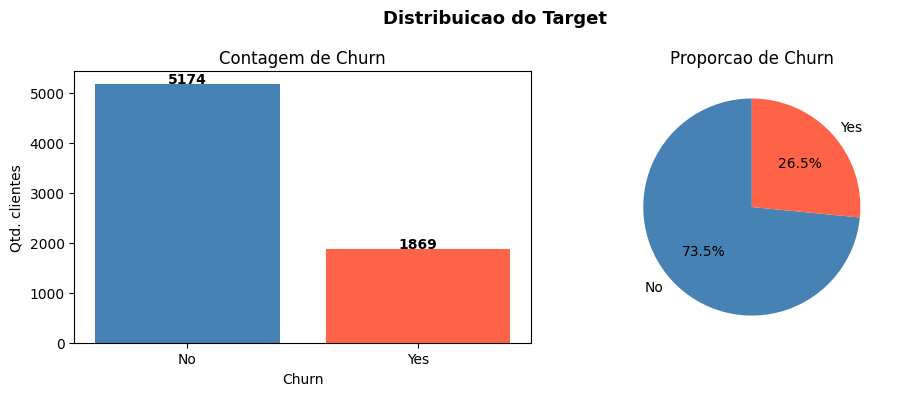

Churn
No     73.46
Yes    26.54


In [5]:
# .value_counts() conta quantas vezes cada valor único aparece na coluna.
# Resultado: "No" aparece X vezes, "Yes" aparece Y vezes.
churn_counts = df['Churn'].value_counts()

# normalize=True divide cada contagem pelo total de registros → resultado em proporção (0 a 1).
# Multiplicando por 100, convertemos para percentual.
churn_pct = df['Churn'].value_counts(normalize=True) * 100

# --- Criação da figura com dois gráficos lado a lado ---
# fig  → a figura inteira (o "canvas" em branco)
# axes → array com os dois subgráficos (eixos)
# plt.subplots(linhas, colunas) → cria uma grade de gráficos
# figsize=(largura, altura) define o tamanho em polegadas
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 linha, 2 colunas de gráficos

# ---- GRÁFICO 1: Barras (contagem absoluta) ----
axes[0].bar(
    churn_counts.index,             # Eixo X: rótulos "No" e "Yes"
    churn_counts.values,            # Altura de cada barra: quantidade de clientes
    color=['steelblue', 'tomato']   # Cores: azul para "No", vermelho para "Yes"
)
axes[0].set_title('Contagem de Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Qtd. clientes')

# Adiciona os números exatos sobre cada barra para facilitar a leitura
for i, v in enumerate(churn_counts.values):
    # enumerate() percorre a lista retornando pares (índice, valor): (0, 5174), (1, 1869)
    # axes[0].text(x, y, texto) escreve um texto na posição (x, y) do gráfico
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# ---- GRÁFICO 2: Pizza (proporção percentual) ----
axes[1].pie(
    churn_pct.values,          # Tamanho de cada "fatia" em percentual
    labels=churn_pct.index,    # Rótulos das fatias: "No" e "Yes"
    autopct='%1.1f%%',         # Formato do texto dentro de cada fatia (ex: "26.5%")
    colors=['steelblue', 'tomato'],
    startangle=90              # Ângulo inicial da primeira fatia (0° = direita, 90° = cima)
)
axes[1].set_title('Proporcao de Churn')

plt.suptitle('Distribuicao do Target', fontsize=13, fontweight='bold')
plt.tight_layout()  # Ajusta automaticamente o espaçamento para os gráficos não se sobreporem

# savefig() salva o gráfico como imagem no disco
# dpi=100 → resolução (dots per inch) — quanto maior, mais nítida a imagem
# bbox_inches='tight' → corta as margens brancas desnecessárias ao redor do gráfico
plt.savefig('fig_01_churn_target.png', dpi=100, bbox_inches='tight')
plt.show()

# round(2) arredonda para 2 casas decimais; to_string() converte para texto formatado
print(churn_pct.round(2).to_string())

### 2.2 Análise de Variáveis Numéricas

#### O que são variáveis numéricas?

São colunas que contêm **números** e onde faz sentido calcular média, soma, desvio padrão etc.

No nosso dataset, as variáveis numéricas são:
- `tenure` → tempo do cliente na empresa (em meses)
- `MonthlyCharges` → valor da mensalidade
- `TotalCharges` → valor total pago desde o início do contrato

#### Como analisamos?

Plotamos **histogramas separados por classe de churn**. Um histograma divide o eixo X em intervalos (bins) e conta quantos clientes têm valores naquele intervalo. Comparar os histogramas de clientes que cancelaram vs. os que ficaram revela padrões importantes: em quais faixas de valor o churn é mais comum?

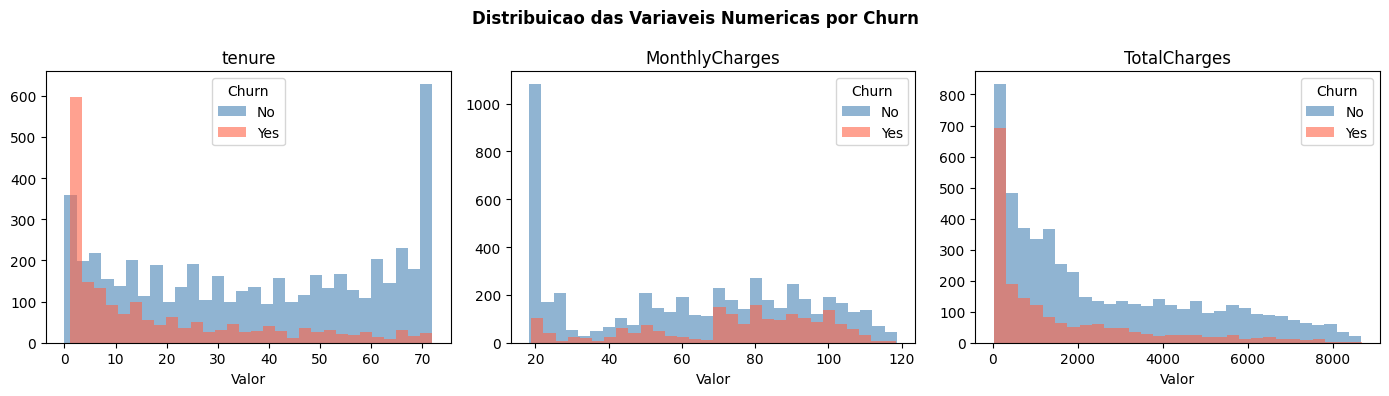

In [6]:
# Criamos uma cópia do DataFrame com .copy() para não alterar o original (df)
# durante o tratamento de TotalCharges. Mudanças em df_plot não afetarão df.
df_plot = df.copy()

# pd.to_numeric() tenta converter a coluna para número.
# errors='coerce' → se encontrar um valor que não é número (ex: espaço " "),
#                   substitui por NaN (Not a Number) em vez de lançar um erro.
df_plot['TotalCharges'] = pd.to_numeric(df_plot['TotalCharges'], errors='coerce')

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Criamos 3 subgráficos lado a lado (1 linha, 3 colunas)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# zip() combina duas listas em pares: (axes[0], 'tenure'), (axes[1], 'MonthlyCharges'), ...
# Isso evita usar índices manuais como axes[0], axes[1], axes[2].
for ax, col in zip(axes, num_cols):

    # Plotamos um histograma para CADA classe (No e Yes) no mesmo eixo,
    # usando cores e transparência diferentes para poder diferenciar.
    for label, color in [('No', 'steelblue'), ('Yes', 'tomato')]:

        # df[df['coluna'] == valor] → filtra apenas as linhas onde a condição é True
        # É o equivalente ao "WHERE Churn = 'No'" do SQL.
        subset = df_plot[df_plot['Churn'] == label][col].dropna()
        # .dropna() remove os valores NaN antes de plotar (evita erros)

        ax.hist(
            subset,
            bins=30,      # Divide o eixo X em 30 intervalos de igual largura
            alpha=0.6,    # Transparência de 60% — permite ver os histogramas sobrepostos
            label=label,  # Rótulo para a legenda
            color=color
        )
    ax.set_title(col)
    ax.set_xlabel('Valor')
    ax.legend(title='Churn')  # Legenda que identifica qual cor é cada classe

plt.suptitle('Distribuicao das Variaveis Numericas por Churn', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_02_num_cols.png', dpi=100, bbox_inches='tight')
plt.show()

**Observações:**
- Clientes com **menor tempo de relacionamento (tenure)** têm maior proporção de churn.
- Clientes com **mensalidade mais alta** tendem a cancelar mais.
- `TotalCharges` reflete a combinação de `tenure × MonthlyCharges`.

### 2.3 Análise de Variáveis Categóricas

#### O que são variáveis categóricas?

São colunas que contêm **categorias** (grupos), como "Yes"/"No", "Male"/"Female" ou "Month-to-month"/"One year"/"Two year". Não faz sentido calcular a média de "Male" e "Female" — são apenas rótulos.

#### Como analisamos?

Usamos `pd.crosstab()` para criar uma **tabela cruzada** que mostra, para cada categoria de uma variável, qual é a **proporção de clientes que cancelaram**. Isso revela quais grupos têm maior risco de churn.

Por exemplo: clientes com contrato mensal cancelam mais do que os com contrato anual?

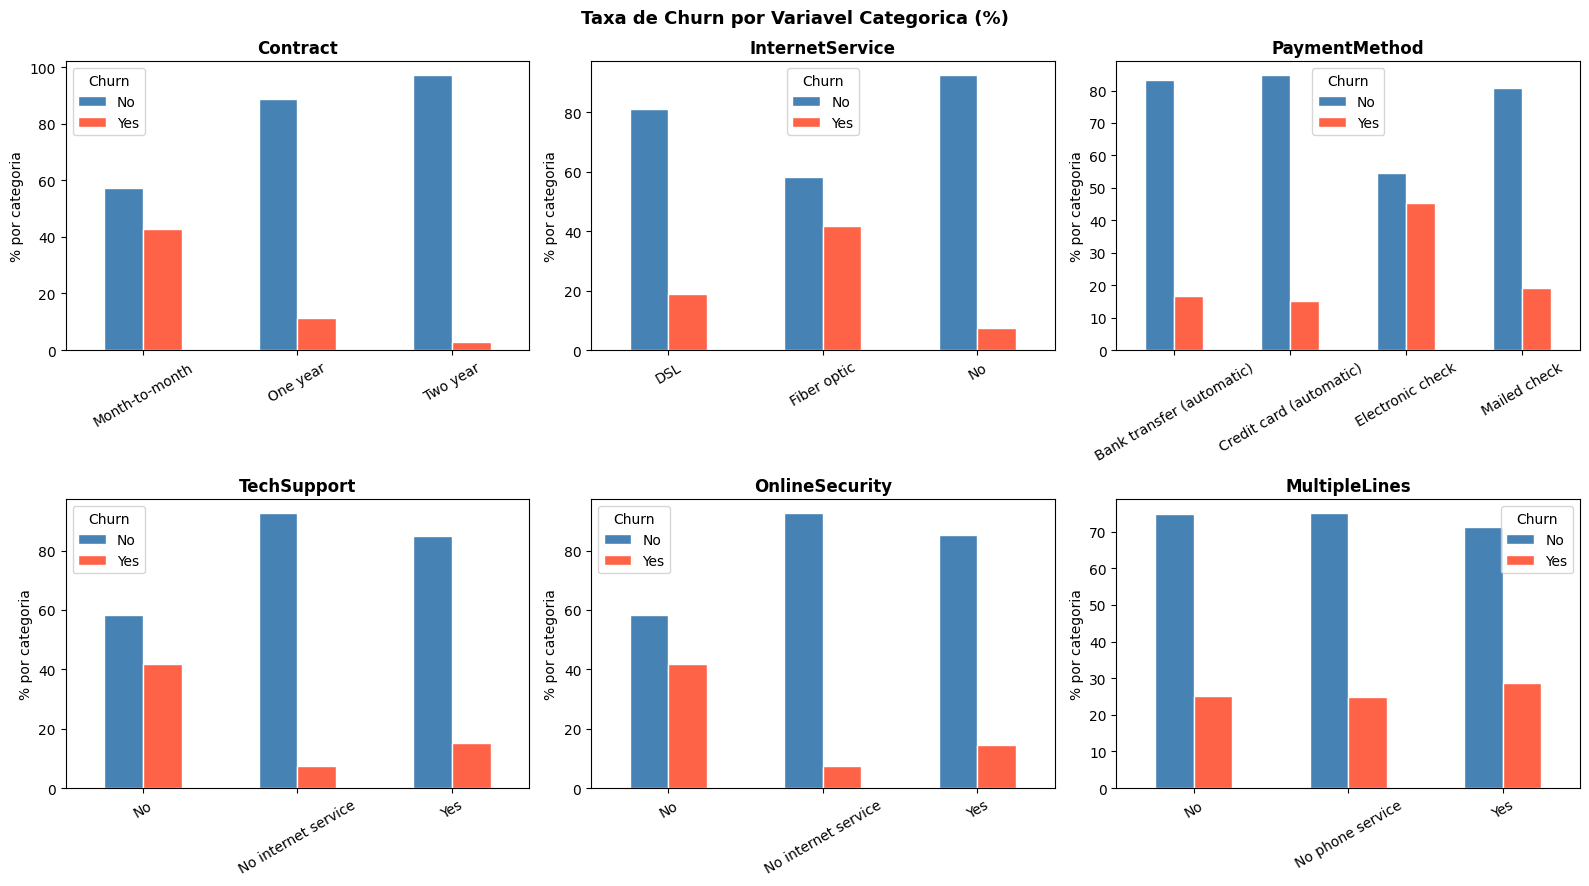

In [7]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod',
            'TechSupport', 'OnlineSecurity', 'MultipleLines']

# Criamos uma grade 2×3 de subgráficos (2 linhas, 3 colunas = 6 gráficos no total)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# .flatten() transforma a grade 2D de eixos em uma lista 1D.
# Sem flatten, precisaríamos acessar com axes[0][0], axes[0][1]...
# Com flatten, acessamos simplesmente com axes[0], axes[1], axes[2]...
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):

    # pd.crosstab() cria uma tabela cruzada entre duas colunas:
    #   Linhas   = categorias da variável analisada (ex: "Month-to-month", "One year")
    #   Colunas  = valores de Churn ("No" e "Yes")
    #
    # normalize='index' → divide cada linha pelo total daquela linha.
    # Resultado: proporção de churn DENTRO de cada categoria (não no dataset todo).
    # Multiplicamos por 100 para obter percentual.
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100

    # .plot(kind='bar') transforma a tabela cruzada em gráfico de barras agrupadas
    ct.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
    # edgecolor='white' → borda branca entre as barras (visual mais limpo)

    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')                         # Remove o rótulo do eixo X (já está no título)
    ax.set_ylabel('% por categoria')
    ax.tick_params(axis='x', rotation=30)    # Gira os rótulos do eixo X em 30° para caber
    ax.legend(title='Churn')

plt.suptitle('Taxa de Churn por Variavel Categorica (%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_03_cat_cols.png', dpi=100, bbox_inches='tight')
plt.show()

**Observações:**
- Contratos **mês a mês** têm taxa de churn muito maior que anuais/bianuais.
- Clientes com **fibra óptica** cancelam mais do que os com DSL.
- Ausência de **segurança online** e **suporte técnico** aumenta o churn.

## 3. Pré-processamento

### Por que precisamos pré-processar os dados?

Redes neurais (e a maioria dos algoritmos de Machine Learning) **não conseguem trabalhar diretamente com texto**, nem com valores em escalas muito diferentes. Precisamos **transformar os dados** em números padronizados antes de treinar.

As etapas são:

| Etapa | O que faz | Por que é necessário |
|:------|:----------|:--------------------|
| **Limpeza** | Trata valores ausentes e inconsistências | Dados sujos geram modelos ruins |
| **Codificação** | Converte texto em números | A rede neural só entende números |
| **Divisão** | Separa treino e teste | Avaliar em dados nunca vistos |
| **Normalização** | Padroniza a escala das features | Evita que features com valores maiores dominem o aprendizado |

### 3.1 Limpeza de Dados

Identificamos dois problemas no dataset:

**Problema 1 — `TotalCharges` está como texto:**
Ao carregar o CSV, o pandas detectou essa coluna como `object` (texto). O motivo: 11 registros possuem um espaço em branco `" "` nessa coluna — são clientes novos com `tenure = 0` que ainda não acumularam cobranças. Vamos converter para número e preencher esses 11 casos com `0`.

**Problema 2 — `customerID` é apenas um identificador:**
O código único do cliente (ex: "7590-VHVEG") não carrega nenhuma informação preditiva sobre churn. Se deixarmos no dataset, o modelo tentaria aprender padrões nele — o que seria ruído. Devemos removê-lo.

In [8]:
# ---- PROBLEMA 1: TotalCharges está como texto ----
# pd.to_numeric() tenta converter cada valor da coluna para número.
# errors='coerce' → se encontrar algo que não é número (ex: " " espaço),
#                   transforma em NaN (Not a Number) em vez de lançar um erro.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Valores nulos por coluna:')
# .isnull() retorna True onde há NaN, False onde há valor normal
# .sum() conta os True (1) por coluna — diz quantos nulos há em cada coluna
# Filtramos apenas as colunas com pelo menos 1 nulo para simplificar o output
print(df.isnull().sum()[df.isnull().sum() > 0])

print('\nRegistros afetados (tenure=0, sem cobrancas acumuladas):')
# Filtramos os 11 registros onde TotalCharges virou NaN após a conversão
print(df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']])
# Observamos que todos têm tenure=0 — são clientes que nunca foram cobrados.
# Faz sentido preencher com 0 (valor total acumulado = zero).

# .fillna(valor) substitui todos os NaN da coluna pelo valor especificado
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# ---- PROBLEMA 2: customerID não tem valor preditivo ----
# .drop() remove linhas ou colunas do DataFrame.
# columns=['customerID'] → especifica que queremos remover essa coluna
# inplace=True → modifica o DataFrame diretamente, sem precisar de df = df.drop(...)
df.drop(columns=['customerID'], inplace=True)

print('\nShape apos limpeza:', df.shape)
# Esperamos (7043, 20) — 7043 linhas, 20 colunas (21 originais menos o customerID)

Valores nulos por coluna:
TotalCharges    11
dtype: int64

Registros afetados (tenure=0, sem cobrancas acumuladas):
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN

Shape apos limpeza: (7043, 20)


### 3.2 Codificação de Variáveis Categóricas

Redes neurais trabalham exclusivamente com **números**. Precisamos converter todas as colunas de texto em representações numéricas. A estratégia depende do tipo da variável:

#### Estratégia 1 — Variáveis binárias (2 categorias)
Colunas com apenas dois valores possíveis (`Yes`/`No`, `Male`/`Female`) são mapeadas diretamente para `1`/`0`.

#### Estratégia 2 — Serviços com categorias redundantes
Colunas como `OnlineSecurity` têm três valores: `"Yes"`, `"No"` e `"No internet service"`. Como a terceira opção tem o mesmo significado prático que `"No"`, simplificamos para binário.

#### Estratégia 3 — One-Hot Encoding (variáveis com múltiplas categorias)
Para colunas com 3+ categorias sem ordem natural (ex: `Contract`), criamos **uma coluna binária para cada categoria**:

```
Contract original     →   Contract_Month-to-month   Contract_One year   Contract_Two year
"Month-to-month"      →          1                        0                   0
"One year"            →          0                        1                   0
"Two year"            →          0                        0                   1
```

> **Por que não usar 0, 1, 2?** Porque isso criaria uma **ordem falsa** — o modelo entenderia que "Two year" (2) é "maior" que "Month-to-month" (0), o que não faz sentido.

In [9]:
# ---- Separamos o target (y) das features (X) ----
# Em Machine Learning, por convenção:
#   X → matriz de features (o que usamos para prever) — letras maiúsculas para matrizes
#   y → vetor de targets (o que queremos prever) — letras minúsculas para vetores

y = (df['Churn'] == 'Yes').astype(int).values
# (df['Churn'] == 'Yes') → cria uma Series de True/False para cada linha
# .astype(int)           → converte True→1, False→0
# .values                → extrai o array NumPy puro (sem o índice do pandas)

X = df.drop(columns=['Churn']).copy()
# Removemos a coluna Churn de X — ela é o target, não uma feature!
# .copy() garante que X seja independente de df

# ---- ESTRATÉGIA 1: Variáveis binárias → mapeamento direto ----
# Um dicionário em Python mapeia chaves a valores: {chave: valor}
# .map(dicionário) substitui cada elemento da Series pelo valor correspondente no dicionário
binary_map  = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    X[col] = X[col].map(binary_map)

# ---- ESTRATÉGIA 2: Serviços — colapsar categorias redundantes ----
# Colunas de serviço têm 3 valores: "Yes", "No" e "No internet/phone service"
# "No internet service" significa que o cliente não tem internet — o serviço também não existe.
# Colapsamos para simplificar: qualquer coisa que não seja "Yes" vira "No".
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    # .replace() substitui valores específicos — sem alterar os demais
    X[col] = X[col].replace({'No internet service': 'No', 'No phone service': 'No'})
    # Agora a coluna tem apenas "Yes" ou "No" → convertemos para 1 ou 0
    X[col] = (X[col] == 'Yes').astype(int)

# ---- ESTRATÉGIA 3: One-Hot Encoding para variáveis nominais ----
# pd.get_dummies() cria colunas binárias para cada categoria de cada coluna especificada.
# drop_first=False → mantemos TODAS as categorias (não há problema de multicolinearidade
#                    perfeita em redes neurais como haveria em regressão linear).
# dtype=int → garante que as novas colunas sejam inteiros (0 e 1), não booleanos.
X = pd.get_dummies(X, columns=['InternetService', 'Contract', 'PaymentMethod'],
                   drop_first=False, dtype=int)

print('Shape apos encoding:', X.shape)
# De 20 colunas, criamos mais colunas via One-Hot → resultado esperado: 26 colunas
print('\nColunas finais:')
print(list(X.columns))

Shape apos encoding: (7043, 26)

Colunas finais:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


### 3.3 Divisão Treino / Teste e Normalização

#### Por que dividir em treino e teste?

Nunca devemos **avaliar o modelo** com os mesmos dados usados para **treiná-lo**. Isso seria como dar as respostas da prova para o aluno estudar e depois usar as mesmas questões — ele memorizaria, mas não aprenderia de verdade.

- **Conjunto de treino (80%)** → o modelo aprende com esses dados
- **Conjunto de teste (20%)** → avaliamos se o modelo generaliza para dados novos que nunca viu

Usamos `stratify=y` para garantir que a **proporção de churn seja a mesma** em treino e teste.

#### Normalização — StandardScaler (Z-score)

Imagine duas features:
- `tenure`: valores entre 0 e 72
- `MonthlyCharges`: valores entre 18 e 118

Sem normalização, o gradiente da rede seria dominado pela feature com maior escala. O **StandardScaler** transforma cada feature para ter **média ≈ 0** e **desvio padrão ≈ 1**:

> z = (x − média) / desvio_padrão

> **Regra de ouro:** o scaler deve ser ajustado (`fit`) **apenas no treino** e depois aplicado (`transform`) no teste. Usar dados do teste no `fit` seria **data leakage** — contaminar o modelo com informações que ele não deveria ter.

In [10]:
# ---- DIVISÃO TREINO / TESTE ----
# train_test_split() embaralha e divide os dados em dois conjuntos.
# Retorna 4 arrays: features de treino, features de teste, targets de treino, targets de teste.
X_train, X_test, y_train, y_test = train_test_split(
    X.values,         # .values converte o DataFrame pandas em array NumPy
    y,
    test_size=0.20,   # 20% dos dados vão para teste; 80% para treino
    random_state=42,  # Garante que a divisão seja sempre a mesma ao rodar novamente
    stratify=y        # Mantém a mesma proporção de churn (26.5%) em treino e teste
)

# ---- NORMALIZAÇÃO (Z-score com StandardScaler) ----
# StandardScaler aplica: z = (x - média) / desvio_padrão
# Após a transformação, cada feature terá média ≈ 0 e desvio padrão ≈ 1.
scaler = StandardScaler()

# fit_transform() no treino: APRENDE a média e o desvio padrão, e já aplica a transformação
X_train = scaler.fit_transform(X_train)

# transform() no teste: usa a média e desvio padrão APRENDIDOS no treino.
# NUNCA usamos fit_transform() no teste — isso seria data leakage!
# (seria como deixar o modelo "espiar" as respostas da prova)
X_test = scaler.transform(X_test)

print(f'Treino : {X_train.shape}  |  Teste: {X_test.shape}')
# Shape esperado: Treino=(5634, 26) Teste=(1409, 26)
# 5634 = 80% de 7043;  1409 = 20% de 7043

print(f'Churn%  — Treino: {y_train.mean()*100:.1f}%  |  Teste: {y_test.mean()*100:.1f}%')
# .mean() em um array 0/1 retorna a proporção de 1s = % de churn
# Devem ser iguais (~26.5%) graças ao stratify=y

Treino : (5634, 26)  |  Teste: (1409, 26)
Churn%  — Treino: 26.5%  |  Teste: 26.5%


## 4. Construção e Treinamento da MLP

### O que é uma Rede Neural MLP?

**MLP (Multi-Layer Perceptron)** é o tipo mais clássico de rede neural. É composta por camadas de **neurônios artificiais** conectados entre si:

```
Entrada      Camada Oculta 1   Camada Oculta 2    Saída
26 features  →  64 neurônios  →  32 neurônios  →  1 neurônio (0 ou 1)
```

Cada **neurônio** recebe os valores da camada anterior, multiplica cada valor pelo seu **peso** (parâmetro aprendível), soma tudo e aplica uma **função de ativação**.

### Conceitos-chave

**Função de Ativação ReLU:**
`ReLU(x) = max(0, x)` — se o valor for negativo, vira zero; se positivo, permanece igual. Introduz não-linearidade, permitindo que a rede aprenda padrões complexos.

**Otimizador Adam:**
Algoritmo que ajusta os pesos da rede iterativamente para **minimizar o erro**. A cada época, calcula o gradiente do erro em relação a cada peso e os atualiza na direção que reduz o erro.

**Regularização L2 (`alpha`):**
Penaliza pesos muito grandes, forçando o modelo a distribuir a informação entre vários neurônios em vez de "decorar" o treino. Ajuda a evitar overfitting.

**Early Stopping:**
Monitora o erro no conjunto de validação a cada época. Se o erro parar de melhorar por `n_iter_no_change` épocas consecutivas, o treinamento é interrompido automaticamente, evitando que o modelo "memorize" o dataset.

In [11]:
# MLPClassifier é a implementação de rede neural MLP do scikit-learn.
# Cada parâmetro abaixo é chamado de "hiperparâmetro" — são as configurações
# que nós (o cientista de dados) definimos ANTES do treinamento.
# Os "parâmetros" (pesos da rede) são aprendidos DURANTE o treinamento.
mlp = MLPClassifier(

    # ARQUITETURA — quantas camadas e quantos neurônios em cada uma
    hidden_layer_sizes=(64, 32),
    # Tupla com o número de neurônios de cada camada OCULTA.
    # (64, 32) → 2 camadas: primeira com 64 neurônios, segunda com 32.
    # A camada de entrada (26 features) e a de saída (1 neurônio) são automáticas.

    activation='relu',
    # Função de ativação das camadas ocultas.
    # 'relu' → ReLU: f(x) = max(0, x)
    # Outras opções: 'tanh', 'logistic' (sigmoid) — mas ReLU é mais eficiente.

    solver='adam',
    # Algoritmo de otimização — como os pesos são atualizados a cada iteração.
    # 'adam' → Adaptive Moment Estimation, combina vantagens do SGD com adaptação automática.
    # Outras opções: 'sgd' (Stochastic Gradient Descent), 'lbfgs'.

    alpha=1e-4,
    # Força da regularização L2 (também chamada de weight decay).
    # Valor muito pequeno → pouca regularização → risco de overfitting.
    # Valor muito grande → muita regularização → risco de underfitting.
    # 1e-4 = 0.0001 (notação científica: 1 × 10⁻⁴).

    batch_size=64,
    # Quantos exemplos são processados antes de cada atualização dos pesos.
    # Batch pequeno → atualização mais frequente, mais ruidosa, mas mais rápida.
    # Batch grande → atualização mais estável, mas requer mais memória.

    learning_rate_init=1e-3,
    # Taxa de aprendizado inicial = 0.001.
    # Controla o tamanho de cada "passo" na atualização dos pesos.
    # Muito grande → modelo não converge; Muito pequeno → treinamento lento demais.

    max_iter=200,
    # Número máximo de épocas (passadas completas pelo dataset de treino).
    # Uma época = o modelo processou todos os 5.634 exemplos de treino uma vez.
    # O early stopping pode parar antes de atingir esse máximo.

    early_stopping=True,
    # Se True, reserva validation_fraction% do treino como validação interna.
    # O treinamento para quando a validação para de melhorar.

    validation_fraction=0.15,
    # 15% do treino é reservado para medir o desempenho a cada época.
    # Esses dados NÃO são usados para atualizar os pesos — só para monitorar.

    n_iter_no_change=15,
    # Se a validação não melhorar por 15 épocas seguidas → treinamento é interrompido.
    # É o critério de parada do early stopping.

    random_state=42,  # Reprodutibilidade
    verbose=True      # Imprime o progresso a cada época (loss e validation score)
)

# .fit() é o método de treinamento — onde o aprendizado de fato acontece.
# O modelo ajusta iterativamente seus pesos para minimizar o erro de classificação.
mlp.fit(X_train, y_train)

# Atributos gerados após o treinamento:
# .n_iter_                → quantas épocas foram treinadas
# .best_validation_score_ → melhor accuracy na validação interna atingida
print(f'\nEpocas treinadas: {mlp.n_iter_}')
print(f'Melhor score na validacao interna: {mlp.best_validation_score_:.4f}')

Iteration 1, loss = 0.48220266
Validation score: 0.789598
Iteration 2, loss = 0.42472028
Validation score: 0.809693
Iteration 3, loss = 0.41565298
Validation score: 0.815603
Iteration 4, loss = 0.41044030
Validation score: 0.819149
Iteration 5, loss = 0.40598269
Validation score: 0.808511
Iteration 6, loss = 0.40274776
Validation score: 0.819149
Iteration 7, loss = 0.39986857
Validation score: 0.814421
Iteration 8, loss = 0.39693372
Validation score: 0.821513
Iteration 9, loss = 0.39364394
Validation score: 0.817967
Iteration 10, loss = 0.39108465
Validation score: 0.816785
Iteration 11, loss = 0.38807056
Validation score: 0.812057
Iteration 12, loss = 0.38514232
Validation score: 0.814421
Iteration 13, loss = 0.38376010
Validation score: 0.814421
Iteration 14, loss = 0.38203008
Validation score: 0.808511
Iteration 15, loss = 0.37961227
Validation score: 0.812057
Iteration 16, loss = 0.37615723
Validation score: 0.813239
Iteration 17, loss = 0.37297717
Validation score: 0.810875
Iterat

## 5. Avaliação do Modelo

### Como sabemos se o modelo aprendeu bem?

Após o treinamento, avaliamos o modelo exclusivamente com dados do **conjunto de teste** — dados que ele **nunca viu durante o treinamento**.

### Por que não usar apenas Accuracy (acurácia)?

Com 73.5% de clientes sem churn, um modelo que **sempre prevê "Não Churn"** teria 73.5% de acurácia sem aprender absolutamente nada! Em datasets desbalanceados, precisamos de métricas mais informativas.

### As métricas que usaremos

Para entender as métricas, precisamos dos 4 tipos de resultado possíveis:

| | Modelo previu: **Churn** | Modelo previu: **Não Churn** |
|---|---|---|
| **Era de fato: Churn** | Verdadeiro Positivo (VP) ✅ | Falso Negativo (FN) ❌ |
| **Era de fato: Não Churn** | Falso Positivo (FP) ❌ | Verdadeiro Negativo (VN) ✅ |

- **Precision** = VP / (VP + FP) → "Quando previmos churn, acertamos quantas vezes?"
- **Recall** = VP / (VP + FN) → "De todos os churns reais, quantos detectamos?"
- **F1-score** = média harmônica entre Precision e Recall
- **AUC-ROC** → qualidade geral, independente do threshold (0.5 = aleatório, 1.0 = perfeito)

> No contexto de churn, **Recall costuma ser mais crítico para o negócio**: é pior deixar de identificar um cliente que vai cancelar (FN = perdemos o cliente) do que acionar um cliente que ficaria (FP = custo de retenção desnecessário).

### 5.1 Curvas de Aprendizado — Análise de Overfitting/Underfitting

As curvas de aprendizado mostram como o **erro evoluiu** ao longo das épocas de treinamento. São a principal ferramenta para diagnosticar problemas no treinamento de redes neurais.

#### Os três cenários possíveis:

| Cenário | Loss de Treino | Loss de Validação | Causa | Solução |
|:--------|:--------------|:-----------------|:------|:--------|
| **Underfitting** | Alta, não converge | Alta | Modelo simples demais | Mais neurônios, mais camadas, menos regularização |
| **Overfitting** | Baixa (cai) | Sobe ou fica estagnada | Modelo memorizou o treino | Regularização L2, Dropout, early stopping, mais dados |
| **Bem ajustado** | Baixa e convergindo | Acompanha o treino | Equilíbrio bias-variância | Nada a fazer — modelo adequado! |

#### O que é a Loss Function (Função de Perda)?

É uma medida de **quão erradas estão as previsões** do modelo. Para classificação binária, usamos a **Binary Cross-Entropy**: quanto maior, mais erros o modelo está cometendo. O objetivo do treinamento é **minimizar** essa função.

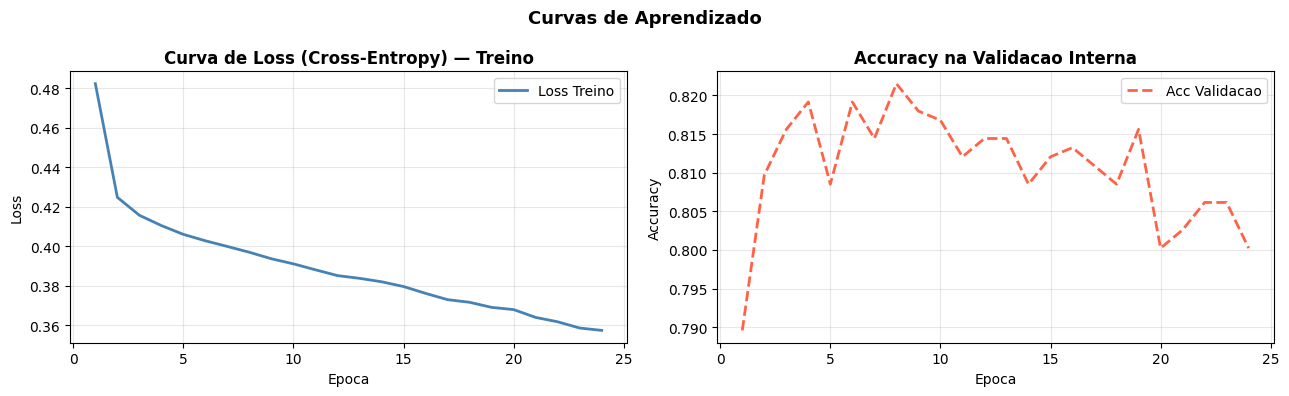

Loss final treino        : 0.3574
Melhor accuracy validacao: 0.8215

DIAGNOSTICO: modelo BEM AJUSTADO
  A loss converge e a validacao acompanha — bom equilíbrio bias-variância.


In [12]:
# .loss_curve_ → lista com o valor da loss ao final de CADA época de treino.
# Quanto menor a loss, melhor o modelo está aprendendo.
train_loss = mlp.loss_curve_

# .validation_scores_ → lista com a accuracy de VALIDAÇÃO ao final de cada época.
# (disponível apenas quando early_stopping=True)
# Queremos que essa accuracy suba ao longo das épocas.
val_loss = mlp.validation_scores_

# range(1, N+1) cria uma sequência: 1, 2, 3, ..., N — usada como eixo X (épocas)
epochs = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ---- GRÁFICO 1: Curva de Loss de Treino ----
# Esperamos que essa curva caia (erros diminuem conforme o modelo aprende)
axes[0].plot(epochs, train_loss, color='steelblue', lw=2, label='Loss Treino')
axes[0].set_title('Curva de Loss (Cross-Entropy) — Treino', fontweight='bold')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)  # Adiciona grade com 30% de opacidade (discreta, não distrai)

# ---- GRÁFICO 2: Accuracy de Validação por Época ----
# Esperamos que essa curva SUBA (modelo acerta mais na validação conforme aprende)
axes[1].plot(epochs, val_loss, color='tomato', lw=2, linestyle='--', label='Acc Validacao')
# linestyle='--' → linha tracejada (para diferenciar visualmente do treino)
axes[1].set_title('Accuracy na Validacao Interna', fontweight='bold')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Curvas de Aprendizado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_04_learning_curves.png', dpi=100, bbox_inches='tight')
plt.show()

# ---- DIAGNÓSTICO AUTOMÁTICO ----
final_loss = train_loss[-1]  # Índice -1 em Python: último elemento da lista
best_val   = max(val_loss)   # max() retorna o maior valor da lista

print(f'Loss final treino        : {final_loss:.4f}')
print(f'Melhor accuracy validacao: {best_val:.4f}')
print()

# Aplicamos regras simples para diagnosticar o estado do treinamento:
if final_loss > 0.55:
    print('DIAGNOSTICO: UNDERFITTING')
    print('  A loss de treino ainda está elevada — o modelo não aprendeu o suficiente.')
    print('  Sugestao: usar uma rede maior ou reduzir a regularizacao (alpha menor).')
elif best_val < 0.73 and final_loss < 0.40:
    print('DIAGNOSTICO: possivel OVERFITTING')
    print('  A loss de treino caiu bem, mas a validacao ficou para trás.')
    print('  Sugestao: aumentar alpha (mais regularizacao) ou coletar mais dados.')
else:
    print('DIAGNOSTICO: modelo BEM AJUSTADO')
    print('  A loss converge e a validacao acompanha — bom equilíbrio bias-variância.')

### 5.2 Métricas de Classificação no Conjunto de Teste

Agora avaliamos o modelo no conjunto de **teste** (dados que ele nunca viu).

O `classification_report` do sklearn exibe um resumo completo para cada classe:

| Métrica | Fórmula | Significado |
|:--------|:--------|:------------|
| **Precision** | VP / (VP + FP) | Dos que previmos como Churn, quantos % eram realmente Churn? |
| **Recall** | VP / (VP + FN) | Dos clientes que realmente cancelaram, quantos % detectamos? |
| **F1-score** | 2 × (P × R) / (P + R) | Média harmônica entre Precision e Recall |
| **Support** | — | Quantidade real de exemplos de cada classe no teste |

A última linha (`accuracy`) mostra o percentual geral de acertos — útil como referência, mas não a métrica principal aqui.

In [13]:
# .predict_proba() retorna a PROBABILIDADE de cada classe para cada exemplo.
# O resultado é uma matriz com 2 colunas:
#   Coluna 0 → probabilidade de "Não Churn"
#   Coluna 1 → probabilidade de "Churn" (que é o que queremos)
# [:, 1] seleciona a coluna 1 (todas as linhas, segunda coluna)
# Exemplo: y_prob[0] = 0.73 significa "73% de chance desse cliente cancelar"
y_prob = mlp.predict_proba(X_test)[:, 1]

# .predict() aplica o threshold padrão de 0.50:
#   se y_prob >= 0.50 → classifica como Churn (1)
#   se y_prob <  0.50 → classifica como Não Churn (0)
y_pred = mlp.predict(X_test)

print('=' * 55)
print('RELATORIO DE CLASSIFICACAO (threshold = 0.50)')
print('=' * 55)
# classification_report() compara y_test (valores reais) com y_pred (valores previstos)
# Calcula precision, recall, f1-score e support para cada classe
# target_names=['Nao Churn', 'Churn'] → rótulos legíveis para as classes 0 e 1
print(classification_report(y_test, y_pred, target_names=['Nao Churn', 'Churn']))

# roc_auc_score() usa as PROBABILIDADES brutas (y_prob), não as previsões binárias.
# Não depende do threshold — avalia a capacidade geral de separação do modelo.
# 0.5 = aleatório (como jogar cara ou coroa); 1.0 = perfeição absoluta
auc_score = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC: {auc_score:.4f}')

RELATORIO DE CLASSIFICACAO (threshold = 0.50)
              precision    recall  f1-score   support

   Nao Churn       0.83      0.91      0.87      1035
       Churn       0.65      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

AUC-ROC: 0.8393


### 5.3 Matriz de Confusão

A **matriz de confusão** organiza visualmente todos os acertos e erros do modelo em uma tabela 2×2.

```
                   Previsto: Não Churn   Previsto: Churn
Real: Não Churn       VN (acerto)          FP (erro)
Real: Churn           FN (erro)            VP (acerto)
```

- **Diagonal principal** (VN + VP) → previsões **corretas**
- **Fora da diagonal** (FP + FN) → **erros** do modelo

#### Impacto no negócio

| Tipo de erro | O que acontece | Custo para o negócio |
|:-------------|:--------------|:--------------------|
| **Falso Negativo (FN)** | Cliente vai cancelar mas o modelo não detectou | Alto — perdemos o cliente sem intervir |
| **Falso Positivo (FP)** | Modelo previu churn mas cliente ficaria | Menor — gastamos recursos de retenção desnecessariamente |

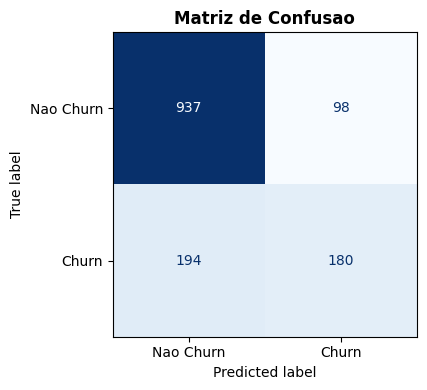

Verdadeiros Positivos (VP):  180  — churn corretamente identificado ✅
Verdadeiros Negativos (VN):  937  — retencao corretamente identificada ✅
Falsos Positivos      (FP):   98  — alarme falso (custo: contato desnecessario) ❌
Falsos Negativos      (FN):  194  — churn nao detectado (custo: perda do cliente) ❌


In [14]:
# confusion_matrix() compara os valores reais (y_test) com os previstos (y_pred)
# e retorna uma matriz 2×2 no formato: [[VN, FP], [FN, VP]]
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))

# ConfusionMatrixDisplay é uma classe do sklearn para visualizar a matriz de confusão.
# Ela cuida automaticamente dos rótulos, cores e valores dentro de cada célula.
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Nao Churn', 'Churn']  # Rótulos para as classes 0 e 1
)
disp.plot(
    ax=ax,
    colorbar=False,   # Remove a barra de cores (não é necessária com apenas 2 classes)
    cmap='Blues'      # Mapa de cores azul: células com mais exemplos ficam mais escuras
)
ax.set_title('Matriz de Confusao', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_05_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# .ravel() "achata" a matriz 2D em 1D: [[VN, FP], [FN, VP]] → [VN, FP, FN, VP]
# Usamos unpacking para nomear cada valor (muito mais legível que cm[0][0], cm[0][1]...)
tn, fp, fn, tp = cm.ravel()
# tn = True Negatives  → previu "Não Churn" e estava certo ✅
# fp = False Positives → previu "Churn" mas estava errado ❌ (alarme falso)
# fn = False Negatives → previu "Não Churn" mas estava errado ❌ (churn não detectado)
# tp = True Positives  → previu "Churn" e estava certo ✅

print(f'Verdadeiros Positivos (VP): {tp:4d}  — churn corretamente identificado ✅')
print(f'Verdadeiros Negativos (VN): {tn:4d}  — retencao corretamente identificada ✅')
print(f'Falsos Positivos      (FP): {fp:4d}  — alarme falso (custo: contato desnecessario) ❌')
print(f'Falsos Negativos      (FN): {fn:4d}  — churn nao detectado (custo: perda do cliente) ❌')

### 5.4 Curva ROC (Receiver Operating Characteristic)

A curva ROC mostra o **trade-off** entre dois tipos de acerto/erro para diferentes thresholds:

- **TPR (True Positive Rate) = Recall** → proporção de churns reais que detectamos
- **FPR (False Positive Rate)** → proporção de não-churns que classificamos incorretamente como churn

Para cada threshold possível (de 0.0 a 1.0), calculamos o par (FPR, TPR) e plotamos o ponto. A curva une todos esses pontos.

#### Como interpretar?

- A **linha diagonal tracejada** representa um classificador completamente aleatório (AUC = 0.5)
- Quanto mais a curva se aproxima do **canto superior esquerdo** (FPR = 0, TPR = 1), melhor
- A **área sob a curva (AUC)** resume a qualidade geral: um classificador perfeito teria AUC = 1.0
- A vantagem da AUC é que ela **não depende do threshold** escolhido

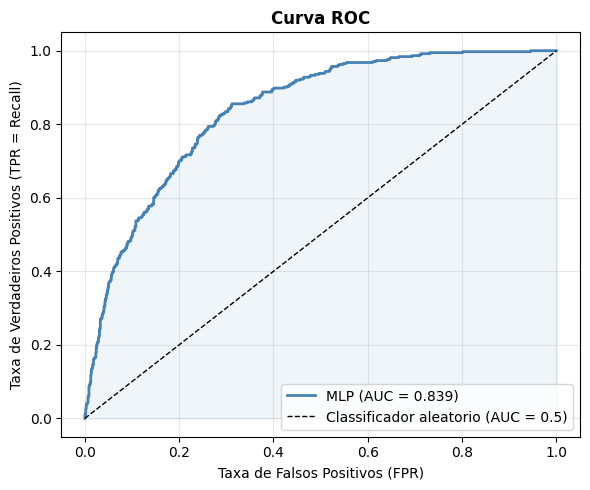

In [15]:
# roc_curve() calcula, para cada threshold possível, os valores de FPR e TPR.
# fpr  → False Positive Rate: proporção de não-churns erroneamente previstos como churn
# tpr  → True Positive Rate (Recall): proporção de churns corretamente identificados
# _    → os thresholds correspondentes (não precisamos plotá-los)
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))

# Linha da curva ROC do nosso modelo
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'MLP (AUC = {auc_score:.3f})')

# A linha diagonal representa um classificador aleatório (AUC = 0.5)
# Queremos que nossa curva ROC fique ACIMA e À ESQUERDA dessa linha
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Classificador aleatorio (AUC = 0.5)')

# fill_between() preenche a área entre a curva e o eixo X com uma cor translúcida
# Isso representa visualmente a AUC — quanto maior a área, melhor o modelo
plt.fill_between(fpr, tpr, alpha=0.08, color='steelblue')

plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR = Recall)')
plt.title('Curva ROC', fontweight='bold')
plt.legend(loc='lower right')  # Posiciona a legenda no canto inferior direito
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_06_roc_curve.png', dpi=100, bbox_inches='tight')
plt.show()

### 5.5 Otimização do Threshold de Decisão

Por padrão, o modelo usa **threshold = 0.50**: se a probabilidade prevista for ≥ 50%, classifica como churn.

Mas **0.5 raramente é o threshold ideal!** O threshold ótimo depende do problema de negócio:

- **Threshold mais baixo (ex: 0.30)** → captura mais clientes em risco (Recall ↑), mas gera mais alertas falsos (Precision ↓)
- **Threshold mais alto (ex: 0.70)** → menos alertas falsos (Precision ↑), mas deixa escapar mais churns (Recall ↓)

Nesta análise, encontramos o threshold que **maximiza o F1-score** — uma forma equilibrada de considerar Precision e Recall simultaneamente. Em um cenário real, essa escolha dependeria do custo relativo de cada tipo de erro para a empresa.

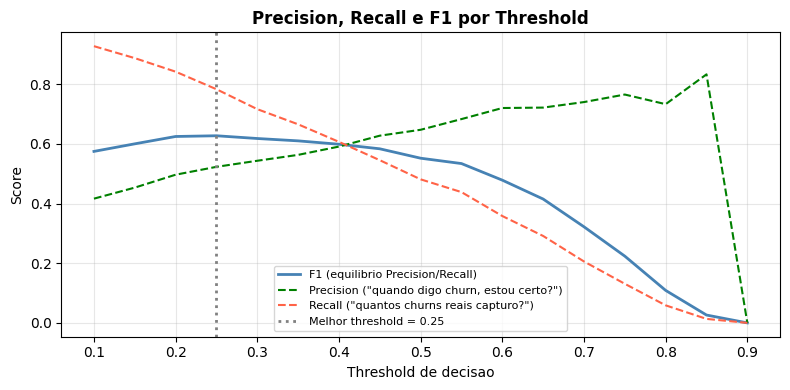

Melhor threshold (max F1): 0.25
F1 no threshold otimo    : 0.6274

Relatorio com threshold otimo (compare com o threshold=0.5 acima):
              precision    recall  f1-score   support

   Nao Churn       0.90      0.74      0.82      1035
       Churn       0.52      0.78      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409



In [16]:
# np.arange(início, fim_exclusivo, passo) → cria um array de valores espaçados uniformemente
# Testamos 17 thresholds de 0.10 a 0.90 (passo de 0.05)
thresholds_range = np.arange(0.10, 0.91, 0.05)

# List comprehension: forma compacta de criar listas aplicando uma expressão a cada elemento
# [expressão for variável in sequência] é equivalente a:
#   result = []
#   for t in thresholds_range:
#       result.append(f1_score(...))
f1_list = [f1_score(y_test, (y_prob >= t).astype(int))
           for t in thresholds_range]
# (y_prob >= t) → cria array True/False: True onde a prob. é >= threshold
# .astype(int)  → converte True→1, False→0 (previsão binária para aquele threshold)

prec_list = [precision_score(y_test, (y_prob >= t).astype(int), zero_division=0)
             for t in thresholds_range]
# zero_division=0 → evita erro quando o denominador é zero (threshold muito alto)

rec_list = [recall_score(y_test, (y_prob >= t).astype(int))
            for t in thresholds_range]

# np.argmax() retorna o ÍNDICE do maior valor no array
best_idx = int(np.argmax(f1_list))
best_thr = thresholds_range[best_idx]  # Usamos o índice para encontrar o threshold

plt.figure(figsize=(8, 4))
plt.plot(thresholds_range, f1_list,   color='steelblue', lw=2,
         label='F1 (equilibrio Precision/Recall)')
plt.plot(thresholds_range, prec_list, color='green',  lw=1.5, linestyle='--',
         label='Precision ("quando digo churn, estou certo?")')
plt.plot(thresholds_range, rec_list,  color='tomato', lw=1.5, linestyle='--',
         label='Recall ("quantos churns reais capturo?")')

# axvline() desenha uma linha VERTICAL no ponto x = best_thr
plt.axvline(best_thr, color='gray', linestyle=':', lw=2,
            label=f'Melhor threshold = {best_thr:.2f}')

plt.xlabel('Threshold de decisao')
plt.ylabel('Score')
plt.title('Precision, Recall e F1 por Threshold', fontweight='bold')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_07_threshold.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'Melhor threshold (max F1): {best_thr:.2f}')
print(f'F1 no threshold otimo    : {f1_list[best_idx]:.4f}')
print()

# Aplicamos o threshold ótimo para gerar previsões finais
y_pred_opt = (y_prob >= best_thr).astype(int)
print('Relatorio com threshold otimo (compare com o threshold=0.5 acima):')
print(classification_report(y_test, y_pred_opt, target_names=['Nao Churn', 'Churn']))

## 6. Experimento: Comparação de Arquiteturas

Uma das principais decisões ao criar uma rede neural é **escolher o tamanho certo**. Redes muito pequenas não aprendem (underfitting); redes muito grandes "decoram" o treino (overfitting).

Vamos treinar 3 variações e comparar os resultados para **ver empiricamente** os conceitos de bias-variance tradeoff:

| Arquitetura | Configuração | Problema esperado | Por que? |
|:-----------|:------------|:-----------------:|:---------|
| Pequena | 1 camada com 4 neurônios | Underfitting | Poucos parâmetros para capturar os padrões |
| Adequada | 2 camadas: 64 → 32 | Equilíbrio | Capacidade suficiente com regularização adequada |
| Grande sem regularização | 3 camadas: 256 → 128 → 64, alpha≈0 | Overfitting | Muitos parâmetros, sem penalização para pesos grandes |

In [17]:
# Dicionário de configurações: cada chave é o nome do experimento,
# cada valor é outro dicionário com os hiperparâmetros específicos daquele experimento.
configs = {
    'Pequena\n(underfitting)': dict(
        hidden_layer_sizes=(4,),   # Apenas 4 neurônios em 1 camada oculta
        alpha=1e-4,                # Regularização padrão
        max_iter=200),

    'Adequada\n(balanceada)': dict(
        hidden_layer_sizes=(64, 32),  # Nossa arquitetura principal
        alpha=1e-4,
        max_iter=200),

    'Grande sem reg.\n(risco overfit)': dict(
        hidden_layer_sizes=(256, 128, 64),  # Rede com 3 camadas grandes
        alpha=1e-8,                         # Regularização quase nula (≈ sem regularização)
        max_iter=200),
}

results = {}  # Dicionário para guardar o modelo e métricas de cada experimento

for name, cfg in configs.items():
    # **cfg desempacota o dicionário como argumentos nomeados para o MLPClassifier.
    # dict(a=1, b=2) → MLPClassifier(a=1, b=2) — mais compacto que listar tudo na mão.
    m = MLPClassifier(
        **cfg,
        activation='relu', solver='adam', batch_size=64,
        learning_rate_init=1e-3,
        early_stopping=True, validation_fraction=0.15, n_iter_no_change=15,
        random_state=42,
        verbose=False   # Silencia o progresso para manter o output limpo
    )
    m.fit(X_train, y_train)  # Treinamos o modelo

    # Avaliamos no conjunto de teste
    prob = m.predict_proba(X_test)[:, 1]
    auc  = roc_auc_score(y_test, prob)
    f1   = f1_score(y_test, m.predict(X_test))

    # Guardamos os resultados para plotar depois
    results[name] = {'model': m, 'auc': auc, 'f1': f1}

    # chr(10) é o código ASCII do caractere '\n' (nova linha)
    # Usamos para remover a quebra de linha do nome no print
    print(f'{name.replace(chr(10), " "):35s} | Epocas: {m.n_iter_:3d} | AUC: {auc:.4f} | F1: {f1:.4f}')

Pequena (underfitting)              | Epocas: 105 | AUC: 0.8342 | F1: 0.6000
Adequada (balanceada)               | Epocas:  24 | AUC: 0.8393 | F1: 0.5521
Grande sem reg. (risco overfit)     | Epocas:  18 | AUC: 0.8380 | F1: 0.5942


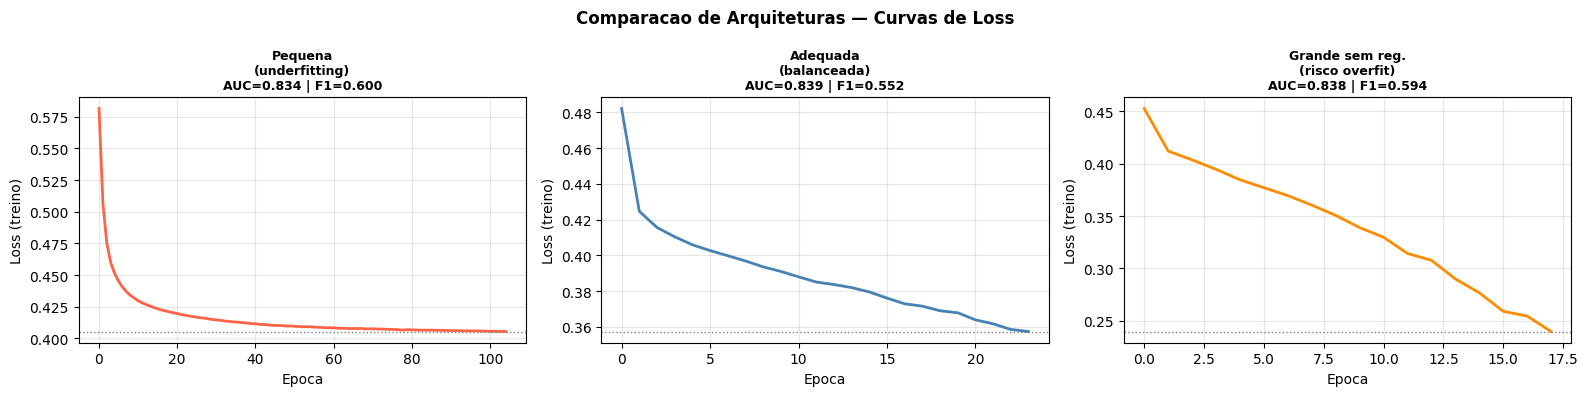

In [18]:
# Criamos 3 gráficos lado a lado, um para cada arquitetura
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ['tomato', 'steelblue', 'darkorange']

# zip() combina as três listas em triplas: (eixo, (nome, resultado), cor)
# Isso permite iterar sobre os três ao mesmo tempo sem usar índices manuais
for ax, (name, res), color in zip(axes, results.items(), colors):
    m = res['model']

    # Plotamos a curva de loss do treino para cada arquitetura
    # m.loss_curve_ → lista com a loss ao fim de cada época
    ax.plot(m.loss_curve_, color=color, lw=2, label='Loss Treino')

    # Linha pontilhada horizontal no valor mínimo da loss atingido
    # (referência visual do melhor ponto do treinamento)
    ax.axhline(min(m.loss_curve_), color='gray', linestyle=':', lw=1)

    # No título incluímos o nome + métricas para comparar de forma integrada
    ax.set_title(f'{name}\nAUC={res["auc"]:.3f} | F1={res["f1"]:.3f}',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Loss (treino)')
    ax.grid(alpha=0.3)

plt.suptitle('Comparacao de Arquiteturas — Curvas de Loss', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_08_architecture_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

### Interpretação das Curvas

| Arquitetura | Comportamento esperado | Diagnóstico |
|---|---|---|
| Pequena (4 neurônios) | Loss alta, converge lentamente | **Underfitting**: capacidade insuficiente para capturar os padrões dos dados |
| Adequada (64→32) | Loss cai progressivamente, validação acompanha | **Ajuste adequado**: bias-variance equilibrados |
| Grande sem reg. (256→128→64) | Loss de treino baixa mas generalização limitada | **Risco de overfitting**: memoriza o treino; regularização L2 baixa piora |

> **Underfitting** → model com pouca capacidade ou poucas épocas  
> **Overfitting** → modelo muito complexo sem regularização adequada

## 7. Resumo dos Resultados

A tabela abaixo consolida os resultados dos três experimentos para facilitar a comparação lado a lado. Observe como diferentes arquiteturas e graus de regularização afetam as métricas finais e o número de épocas necessárias para convergir.

In [19]:
# Construímos uma lista de dicionários — cada dicionário representa uma linha da tabela
summary_rows = []
for name, res in results.items():
    m = res['model']
    summary_rows.append({
        'Arquitetura':     name.replace('\n', ' '),    # Remove '\n' do nome
        'Camadas ocultas': str(m.hidden_layer_sizes),  # Converte tupla em string legível
        'Alpha (L2)':      m.alpha,                    # Regularização usada
        'Epocas':          m.n_iter_,                  # Quantas épocas até o early stopping
        'AUC-ROC':         round(res['auc'], 4),       # round() arredonda para N casas decimais
        'F1 (Churn)':      round(res['f1'], 4)
    })

# pd.DataFrame() converte a lista de dicionários em DataFrame:
# cada dicionário → uma linha; cada chave → uma coluna
summary_df = pd.DataFrame(summary_rows)

# to_string(index=False) formata o DataFrame como texto sem os números de índice das linhas
print(summary_df.to_string(index=False))

                    Arquitetura Camadas ocultas   Alpha (L2)  Epocas  AUC-ROC  F1 (Churn)
         Pequena (underfitting)            (4,) 1.000000e-04     105   0.8342      0.6000
          Adequada (balanceada)        (64, 32) 1.000000e-04      24   0.8393      0.5521
Grande sem reg. (risco overfit)  (256, 128, 64) 1.000000e-08      18   0.8380      0.5942


## 8. Conclusões

### Resultado do Modelo Principal (64→32, alpha=1e-4)

| Métrica | Valor |
|---|---|
| AUC-ROC | *ver output acima* |
| Precision (Churn) | *ver relatório* |
| Recall (Churn) | *ver relatório* |
| F1 (Churn) | *ver relatório* |

### Aprendizados

**1. Pré-processamento é crítico:**
- `TotalCharges` estava como string com espaços — convertemos e imputamos.
- Variáveis categóricas com "No internet service" foram colapsadas para reduzir dimensionalidade.
- Normalização Z-score é essencial para redes com gradiente.

**2. Desbalanceamento de classes (~26% churn):**
- Ajustar o threshold de 0.5 para valores menores (ex: 0.35–0.40) aumenta o **Recall**,
  priorizando a identificação de churners (a decisão depende do custo do negócio).

**3. Overfitting vs Underfitting:**
- Rede **pequena (4 neurônios)**: loss de treino alta, não converge → underfitting.
- Rede **grande sem regularização**: memoriza o treino, baixa generalização → overfitting.
- Rede **adequada com L2 e early stopping**: melhor AUC e F1.

**4. Regularização:**
- `alpha` (L2 weight decay) e `early_stopping` são suficientes para este dataset tabular.
- Em frameworks como PyTorch/Keras, adicionar Dropout e BatchNormalization traz mais controle.

### Próximos Passos
- Usar SHAP para interpretar quais features mais contribuem para o churn.
- Comparar MLP com modelos ensemble (XGBoost, Random Forest).
- Explorar arquiteturas mais profundas com PyTorch/TensorFlow quando disponíveis.